# 3.2. 진동하는 막 — 2차원 문제

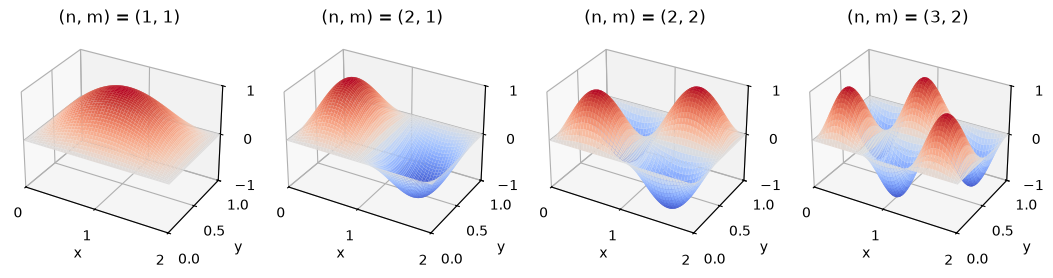

In [1]:
import numpy as np
import matplotlib.pyplot as plt

a, b = 2.0, 1.0
x, y = np.meshgrid(np.linspace(0, a, 100), np.linspace(0, b, 100))


def mode(n, m):
    return np.sin(n * np.pi * x / a) * np.sin(m * np.pi * y / b)


fig = plt.figure(figsize=(13, 4))

for i, (n, m) in enumerate([(1, 1), (2, 1), (2, 2), (3, 2)], 1):
    ax = fig.add_subplot(1, 4, i, projection="3d")
    ax.plot_surface(x, y, mode(n, m), cmap="coolwarm", vmin=-1, vmax=1, linewidth=0)
    ax.set_xlim(0, 2)
    ax.set_ylim(0, 1)
    ax.set_zlim(-1, 1)
    ax.set_box_aspect((1.5, 1, 1))
    ax.set_title(f"(n, m) = ({n}, {m})", fontsize=12)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 0.5, 1])
    ax.set_zticks([-1, 0, 1])

plt.show()

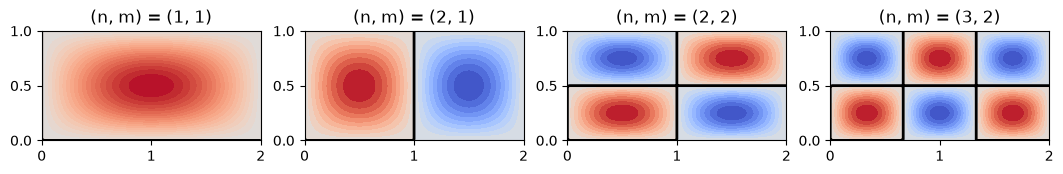

In [2]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))

for ax, (n, m) in zip(axes, [(1, 1), (2, 1), (2, 2), (3, 2)]):
    z = mode(n, m)
    ax.contourf(x, y, z, levels=20, cmap="coolwarm", vmin=-1, vmax=1)
    ax.contour(x, y, z, levels=[0], colors="black", linewidths=2)
    ax.set_aspect("equal")
    ax.set_xticks([0, 1, 2])
    ax.set_yticks([0, 0.5, 1])
    ax.set_title(f"(n, m) = ({n}, {m})", fontsize=12)

plt.show()

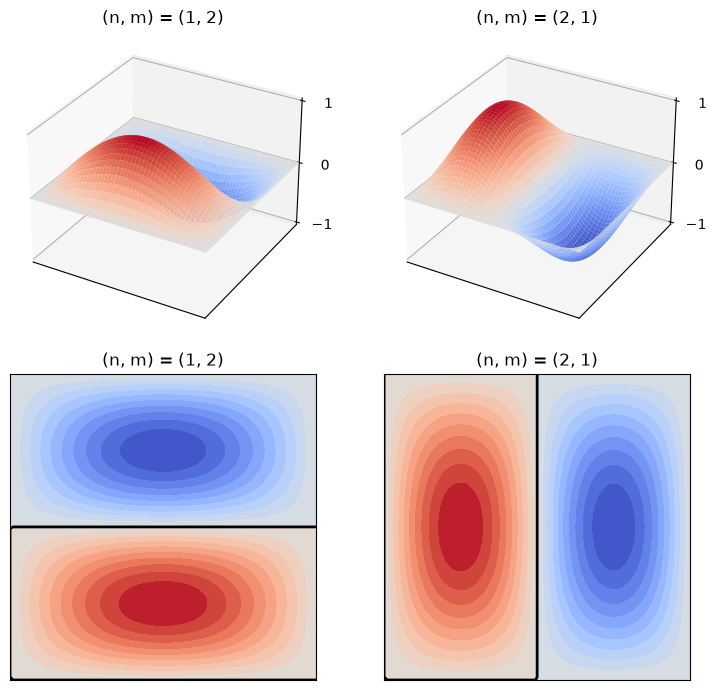

In [3]:
a, b = 1.0, 1.0
x, y = np.meshgrid(np.linspace(0, a, 100), np.linspace(0, b, 100))


def mode(n, m):
    return np.sin(n * np.pi * x / a) * np.sin(m * np.pi * y / b)


fig = plt.figure(figsize=(8, 7))

for i, (n, m) in enumerate([(1, 2), (2, 1)], 1):
    ax = fig.add_subplot(2, 2, i, projection="3d")
    ax.plot_surface(x, y, mode(n, m), cmap="coolwarm", vmin=-1, vmax=1, linewidth=0)
    ax.set_title(f"(n, m) = ({n}, {m})", fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([-1, 0, 1])

    ax2 = fig.add_subplot(2, 2, i + 2)
    ax2.contourf(x, y, mode(n, m), levels=20, cmap="coolwarm", vmin=-1, vmax=1)
    ax2.contour(x, y, mode(n, m), levels=[0], colors="black", linewidths=2)
    ax2.set_aspect("equal")
    ax2.set_xticks([])
    ax2.set_yticks([])
    ax2.set_title(f"(n, m) = ({n}, {m})", fontsize=12)

plt.tight_layout()
plt.show()

In [4]:
def frequency(n, m, a, b):
    # v = 1이라고 가정
    return 0.5 * np.sqrt((n / a) ** 2 + (m / b) ** 2)

print("정사각형 (a, b = 1.0)")
print(f"  (1, 2) : {frequency(1, 2, 1, 1):.4f}")
print(f"  (2, 1) : {frequency(2, 1, 1, 1):.4f}")

print("직사각형 (a = 1.0, b = 2.0)")
print(f"  (1, 2) : {frequency(1, 2, 1, 2):.4f}")
print(f"  (2, 1) : {frequency(2, 1, 1, 2):.4f}")

정사각형 (a, b = 1.0)
  (1, 2) : 1.1180
  (2, 1) : 1.1180
직사각형 (a = 1.0, b = 2.0)
  (1, 2) : 0.7071
  (2, 1) : 1.0308


In [5]:
from collections import defaultdict

groups = defaultdict(list)

for n in range(1, 10):
    for m in range(1, 10):
        groups[n**2 + m**2].append((n, m))

for key in sorted(groups)[:10]:
    modes = groups[key]
    tag = f" ← {len(modes)}중 축퇴" if len(modes) > 1 else ""
    print(f"nu ∝ sqrt({key:2d}) = {np.sqrt(key):.4f}   {modes}{tag}")

nu ∝ sqrt( 2) = 1.4142   [(1, 1)]
nu ∝ sqrt( 5) = 2.2361   [(1, 2), (2, 1)] ← 2중 축퇴
nu ∝ sqrt( 8) = 2.8284   [(2, 2)]
nu ∝ sqrt(10) = 3.1623   [(1, 3), (3, 1)] ← 2중 축퇴
nu ∝ sqrt(13) = 3.6056   [(2, 3), (3, 2)] ← 2중 축퇴
nu ∝ sqrt(17) = 4.1231   [(1, 4), (4, 1)] ← 2중 축퇴
nu ∝ sqrt(18) = 4.2426   [(3, 3)]
nu ∝ sqrt(20) = 4.4721   [(2, 4), (4, 2)] ← 2중 축퇴
nu ∝ sqrt(25) = 5.0000   [(3, 4), (4, 3)] ← 2중 축퇴
nu ∝ sqrt(26) = 5.0990   [(1, 5), (5, 1)] ← 2중 축퇴


In [6]:
for key in sorted(groups):
    modes = groups[key]
    if len(modes) > 2:
        tag = f" ← {len(modes)}중 축퇴" if len(modes) > 1 else ""
        print(f"nu ∝ sqrt({key:2d}) = {np.sqrt(key):.4f}   {modes}{tag}")

nu ∝ sqrt(50) = 7.0711   [(1, 7), (5, 5), (7, 1)] ← 3중 축퇴
nu ∝ sqrt(65) = 8.0623   [(1, 8), (4, 7), (7, 4), (8, 1)] ← 4중 축퇴
nu ∝ sqrt(85) = 9.2195   [(2, 9), (6, 7), (7, 6), (9, 2)] ← 4중 축퇴
